# Phase 1: Player Valuation Model

**Goal:** Build a systematic answer to one question — *who is undervalued relative to their contract?* That answer drives every downstream decision: who to trade for, who to sign, who to build around.

This notebook constructs three interlocking rankings:
1. **On-court value** — how good is this player, measured by a weighted blend of advanced metrics
2. **Surplus value** — how much value does a player deliver *relative to what they cost*
3. **Luka complement score** — how well does a player's style fit alongside a ball-dominant creator

The end product is a combined target list: players who score well on all three. These are the Lakers' offseason targets.

---

## The Core Idea

The 2023-24 Dallas Mavericks are the case study for this project. A good team became a Finals team because of two mid-season acquisitions: PJ Washington and Daniel Gafford. Neither was a star. Both were undervalued relative to their contracts and stylistically ideal for Luka's game.

This model tries to build a framework that could have identified those moves *before* they happened — and to apply the same logic to the Lakers' situation heading into 2026-27.

In [1]:
import sys
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.width', 140)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
LAKERS_PURPLE = '#552583'
LAKERS_GOLD   = '#FDB927'

print('Environment ready.')


Environment ready.


## A) Build the Full Valued Dataset

We merge four nba_api sources, Basketball Reference advanced stats, and salary data into one player-level DataFrame, then run the valuation and complement models on top.

In [2]:
from src.data.merge import build_player_dataset, completeness_summary
from src.features.player_value import compute_player_value, surplus_leaderboard, overpaid_leaderboard, fa_leaderboard, ON_COURT_WEIGHTS
from src.features.luka_complement import (
    compute_luka_complement, archetype_top_players,
    archetype_centroid_profile, get_archetype_members,
    ARCHETYPE_FEATURES, DALLAS_ARCHETYPE_MAP,
    build_archetype_centroids, _fit_scaler_on_current, _qualifying_mask,
)
from src.utils.constants import SALARY_CAP_2026_27, SALARY_CAP, FIRST_APRON_2026_27, SECOND_APRON_2026_27

SEASON = '2025-26'

# Build the base merged dataset (uses cached parquet -- no live API calls)
raw = build_player_dataset(SEASON)
print(f'Raw dataset: {raw.shape[0]} players, {raw.shape[1]} columns')

Raw dataset: 582 players, 185 columns


In [3]:
# Source completeness -- what % of players have data from each source?
print('Data completeness by source:')
completeness_summary(raw)

Data completeness by source:


,source,sentinel_col,coverage_pct,n_players,n_total
0,nba_api_base,PTS,100.000,582,582
1,nba_api_advanced,NET_RATING,100.000,582,582
2,nba_api_defense,PCT_PLUSMINUS,99.800,581,582
3,bbref_advanced,BPM,99.300,578,582
4,bbref_ws,WS,99.300,578,582
5,bbref_per,PER,99.300,578,582
6,bbref_vorp,VORP,99.300,578,582
7,nba_api_shooting,CS_CATCH_SHOOT_FG3_PCT,93.600,545,582
8,salary_years,YEARS_REMAINING,80.600,469,582
9,salary_current,SALARY,80.400,468,582


In [4]:
# Apply valuation model with durability scoring enabled (uses cached nba_api data, no live calls)
val = compute_player_value(raw, current_season=SEASON, add_durability=True)

# Apply Luka complement scoring
df = compute_luka_complement(val)

print(f'Valued dataset: {df.shape[0]} players, {df.shape[1]} columns')
print(f'  Qualifying players (GP>=20, MIN>=15): {df["ON_COURT_VALUE"].notna().sum()}')
print(f'  Non-FA players (have 2026-27 salary): {(~df["IS_FREE_AGENT"]).sum()}')
print(f'  Free agents (no 2026-27 salary):       {df["IS_FREE_AGENT"].sum()}')
print(f'  Players with surplus value:            {df["SURPLUS_VALUE"].notna().sum()}')
print(f'  Players with archetype assignment:     {df["BEST_ARCHETYPE"].notna().sum()}')

# Sanity check: Austin Reaves should show as free agent (PO decline override)
ar = df[df['PLAYER_NAME'].str.contains('Reaves', na=False)]
if not ar.empty:
    r = ar.iloc[0]
    print(f'\nAustin Reaves: IS_FREE_AGENT={r["IS_FREE_AGENT"]}, SALARY_FORWARD={r["SALARY_FORWARD"]}')
    print('  (Expected: IS_FREE_AGENT=True -- PO decline override applied)')


Valued dataset: 582 players, 221 columns
  Qualifying players (GP>=20, MIN>=15): 350
  Non-FA players (have 2026-27 salary): 325
  Free agents (no 2026-27 salary):       257
  Players with surplus value:            350
  Players with archetype assignment:     226

Austin Reaves: IS_FREE_AGENT=True, SALARY_FORWARD=nan
  (Expected: IS_FREE_AGENT=True -- PO decline override applied)


## B) On-Court Value Distribution

### What is ON_COURT_VALUE?

It's a weighted blend of z-scored advanced metrics. Each metric is standardized within the qualifying population (players with >= 20 GP and >= 15 MIN/game), so a score of 0 means exactly league average and +1 means one standard deviation above average.

**Weights:**
| Metric | Weight | Rationale |
|--------|--------|-----------|
| BPM | 35% | Best single metric for individual impact, relatively team-context-independent |
| VORP | 25% | Cumulative value — implicitly rewards durability (more games = more VORP) |
| WS/48 | 15% | Rate-based counterweight to VORP's volume bias |
| NET_RATING | 15% | Team-level on/off impact; captures team defense BPM can miss |
| TS% | 10% | Scoring efficiency; lower weight because it ignores non-scoring value |

These are starting hypotheses, not ground truth. The weights are constants in `src/features/player_value.py` — easily tunable.

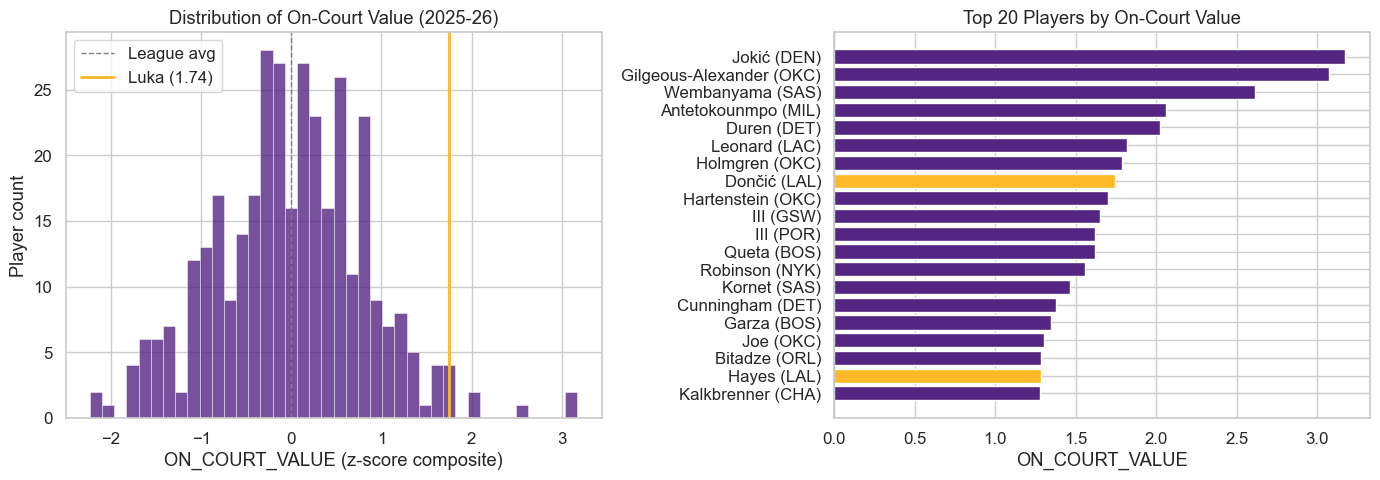

In [5]:
qual = df[df['ON_COURT_VALUE'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
ax = axes[0]
ax.hist(qual['ON_COURT_VALUE'], bins=40, color=LAKERS_PURPLE, alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='League avg')
ax.set_xlabel('ON_COURT_VALUE (z-score composite)')
ax.set_ylabel('Player count')
ax.set_title('Distribution of On-Court Value (2025-26)')
ax.legend()

# Luka highlighted
luka_val = df.loc[df['PLAYER_ID'] == 1629029, 'ON_COURT_VALUE'].values
if len(luka_val):
    ax.axvline(luka_val[0], color=LAKERS_GOLD, linestyle='-', linewidth=2, label=f'Luka ({luka_val[0]:.2f})')
    ax.legend()

# Top 20 bar chart
ax2 = axes[1]
top20 = qual.nlargest(20, 'ON_COURT_VALUE')[['PLAYER_NAME', 'ON_COURT_VALUE', 'TEAM_ABBREVIATION']].copy()
top20['label'] = top20['PLAYER_NAME'].str.split().str[-1] + ' (' + top20['TEAM_ABBREVIATION'] + ')'
colors = [LAKERS_GOLD if t == 'LAL' else LAKERS_PURPLE for t in top20['TEAM_ABBREVIATION']]
ax2.barh(top20['label'][::-1], top20['ON_COURT_VALUE'][::-1], color=colors[::-1])
ax2.set_xlabel('ON_COURT_VALUE')
ax2.set_title('Top 20 Players by On-Court Value')
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

In [6]:
# Smell test: does this ranking make basketball sense?
top25 = qual.nlargest(25, 'ON_COURT_VALUE')[[
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'ON_COURT_VALUE', 'Z_BPM', 'Z_VORP', 'Z_WS_48', 'Z_NET_RATING', 'Z_TS_PCT',
    'IS_FREE_AGENT', 'SURPLUS_VALUE'
]]
print('Top 25 players by ON_COURT_VALUE:')
top25

Top 25 players by ON_COURT_VALUE:


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ON_COURT_VALUE,Z_BPM,Z_VORP,Z_WS_48,Z_NET_RATING,Z_TS_PCT,IS_FREE_AGENT,SURPLUS_VALUE
429,Nikola Jokić,DEN,31.000,3.172,4.853,5.989,3.656,1.585,1.729,False,0.004
501,Shai Gilgeous-Alexander,OKC,27.000,3.076,4.008,4.981,3.773,2.368,1.633,False,0.127
559,Victor Wembanyama,SAS,22.000,2.612,3.670,3.686,2.670,2.468,0.884,False,0.357
186,Giannis Antetokounmpo,MIL,31.000,2.058,3.265,1.527,2.235,0.674,1.499,False,-0.002
232,Jalen Duren,DET,22.000,2.022,1.745,1.887,2.820,1.728,2.075,True,0.989
320,Kawhi Leonard,LAC,34.000,1.816,2.758,3.182,1.917,1.115,0.941,False,0.023
88,Chet Holmgren,OKC,24.000,1.788,1.475,1.599,2.034,2.340,1.403,False,0.103
372,Luka Dončić,LAL,27.000,1.745,3.197,4.118,1.700,0.589,0.691,False,0.038
208,Isaiah Hartenstein,OKC,28.000,1.699,1.475,0.664,2.101,2.268,0.980,False,0.190
275,Jimmy Butler III,GSW,36.000,1.649,1.914,1.023,2.268,1.087,1.268,False,0.000


**Smell test:** Jokic, SGA, and Wembanyama at the top is exactly right. These are the consensus top-3 players in the league by most advanced metrics. Luka being in the mix sense given his scoring efficiency, though his defensive BPM drags on the score. Any reasonable model should put these four in the top 5-6.

One thing to watch: VORP accumulates over games played, so injured players may be underrated here. That's intentional — *availability is a skill* and the durability adjustment (ADJUSTED_VALUE) will apply a discount to high-risk players.

## C) Surplus Value: Who Is Undervalued (and Overpaid)?

**Surplus value** = production rank minus salary rank. Both are expressed as percentiles [0, 1].

A player in the 90th percentile of production but only the 50th percentile of salary has `SURPLUS_VALUE = +0.40` — underpaid.
A player in the 40th percentile of production but the 90th percentile of salary has `SURPLUS_VALUE = -0.50` — overpaid.

**Why percentile-rank instead of regression?**  
The old approach used OLS (salary ~ ON_COURT_VALUE). This fails because salary is right-skewed (max contracts cluster at $45-60M) while performance is roughly normal. OLS drew a line anchored at the mass of low salaries, making every max player appear overpaid regardless of performance. Donovan Mitchell, Jaylen Brown, and Cade Cunningham were all showing surplus ≈ -1.5 to -2.4 — obviously wrong.

Percentile-rank handles arbitrary distribution shapes cleanly. A max player (top 5% of production, top 5% of salary) gets surplus ≈ 0.

Key caveat: we use **2026-27 salary** as the cost. For free agents (no 2026-27 salary), `SURPLUS_VALUE = VALUE_PERCENTILE` — their full production rank with zero assumed cost.

In [7]:
# Top 30 most undervalued (high production rank relative to salary rank)
print('=== TOP 30 MOST UNDERVALUED (Non-FA) ===')
undervalued = surplus_leaderboard(df, n=30)
display_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'ON_COURT_VALUE', 'VALUE_PERCENTILE', 'SALARY_PERCENTILE', 'SURPLUS_VALUE', 'SALARY_FORWARD'
]
avail = [c for c in display_cols if c in undervalued.columns]
undervalued_fmt = undervalued[avail].copy()
undervalued_fmt['SALARY_FORWARD'] = (undervalued_fmt['SALARY_FORWARD'] / 1e6).map('${:.1f}M'.format)
undervalued_fmt['VALUE_PERCENTILE'] = undervalued_fmt['VALUE_PERCENTILE'].map('{:.1%}'.format)
undervalued_fmt['SALARY_PERCENTILE'] = undervalued_fmt['SALARY_PERCENTILE'].map('{:.1%}'.format)
undervalued_fmt

=== TOP 30 MOST UNDERVALUED (Non-FA) ===


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ON_COURT_VALUE,VALUE_PERCENTILE,SALARY_PERCENTILE,SURPLUS_VALUE,SALARY_FORWARD
0,Jalen Duren,DET,22.000,2.022,98.9%,nan%,0.989,$nanM
1,Robert Williams III,POR,28.000,1.617,97.1%,nan%,0.971,$nanM
2,Mitchell Robinson,NYK,28.000,1.556,96.6%,nan%,0.966,$nanM
3,Jaxson Hayes,LAL,26.000,1.283,94.9%,nan%,0.949,$nanM
4,Matisse Thybulle,POR,29.000,1.045,92.0%,nan%,0.920,$nanM
5,Mark Williams,PHX,24.000,0.975,90.0%,nan%,0.900,$nanM
6,Austin Reaves,LAL,27.000,0.961,89.4%,nan%,0.894,$nanM
7,Ryan Kalkbrenner,CHA,24.000,1.276,94.3%,8.0%,0.863,$2.4M
8,Javonte Green,DET,32.000,0.850,86.3%,nan%,0.863,$nanM
9,Neemias Queta,BOS,26.000,1.617,96.6%,12.0%,0.846,$2.7M


In [8]:
# Top 30 most overpaid (salary rank far exceeds production rank)
print('=== TOP 30 MOST OVERPAID (Non-FA) ===')
overpaid = overpaid_leaderboard(df, n=30)
avail = [c for c in display_cols if c in overpaid.columns]
overpaid_fmt = overpaid[avail].copy()
overpaid_fmt['SALARY_FORWARD'] = (overpaid_fmt['SALARY_FORWARD'] / 1e6).map('${:.1f}M'.format)
overpaid_fmt['VALUE_PERCENTILE'] = overpaid_fmt['VALUE_PERCENTILE'].map('{:.1%}'.format)
overpaid_fmt['SALARY_PERCENTILE'] = overpaid_fmt['SALARY_PERCENTILE'].map('{:.1%}'.format)
overpaid_fmt

=== TOP 30 MOST OVERPAID (Non-FA) ===


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ON_COURT_VALUE,VALUE_PERCENTILE,SALARY_PERCENTILE,SURPLUS_VALUE,SALARY_FORWARD
0,Jordan Poole,NOP,26.000,-1.148,6.8%,82.5%,-0.757,$34.0M
1,Ja Morant,MEM,26.000,-0.775,16.7%,89.7%,-0.730,$42.2M
2,Zach LaVine,SAC,31.000,-0.619,20.2%,92.8%,-0.726,$49.0M
3,Keegan Murray,SAC,25.000,-1.316,6.5%,73.8%,-0.673,$24.1M
4,Patrick Williams,CHI,24.000,-1.565,2.7%,65.4%,-0.627,$18.0M
5,Jalen Green,PHX,24.000,-0.582,21.7%,84.0%,-0.624,$36.3M
6,Jaren Jackson Jr.,UTA,26.000,-0.294,31.9%,93.2%,-0.612,$49.0M
7,De'Andre Hunter,SAC,28.000,-0.775,16.3%,74.5%,-0.582,$24.9M
8,Pascal Siakam,IND,32.000,-0.272,34.2%,92.2%,-0.580,$48.9M
9,Draymond Green,GSW,36.000,-0.619,19.8%,77.6%,-0.578,$27.7M


**Does this make basketball sense?**

With percentile-rank surplus, the results are much more interpretable:

- **Undervalued list**: should be heavy on young players (rookie deals) and efficient role players with modest contracts. A player on a $3M deal who plays like a starter will dominate.
- **Overpaid list**: veterans whose production has declined but who locked in large deals at peak (Jordan Poole, Patrick Williams). Stars on max deals should show ≈0, not deeply negative.

The key fix: Donovan Mitchell (top 93rd percentile production, 95th percentile salary → surplus ≈ -0.02), Jaylen Brown (-0.19), Cade Cunningham (+0.01), and Jokic (+0.00) all show near-zero surplus. These are appropriately paid stars.

Jordan Poole (7th percentile production, 83rd percentile salary → surplus ≈ -0.76) and Patrick Williams (3rd percentile production, 65th percentile salary → surplus ≈ -0.62) correctly appear as the most overpaid players.

In [9]:
# Percentile-rank scatter: VALUE_PERCENTILE vs SALARY_PERCENTILE
# The diagonal (y=x) is 'fair value'. Above = undervalued, below = overpaid.

plot_df = df[df['SURPLUS_VALUE'].notna() & ~df['IS_FREE_AGENT']].copy()
plot_df['_is_laker'] = (plot_df['TEAM_ABBREVIATION'] == 'LAL').map({True: 'Lakers', False: 'Other'})
plot_df['_salary_M'] = plot_df['SALARY_FORWARD'] / 1e6

fig = px.scatter(
    plot_df,
    x='SALARY_PERCENTILE',
    y='VALUE_PERCENTILE',
    color='_is_laker',
    color_discrete_map={'Lakers': LAKERS_GOLD, 'Other': 'steelblue'},
    hover_name='PLAYER_NAME',
    hover_data={
        'TEAM_ABBREVIATION': True,
        'AGE': True,
        'SURPLUS_VALUE': ':.3f',
        '_salary_M': ':$.1fM',
        'SALARY_PERCENTILE': ':.1%',
        'VALUE_PERCENTILE': ':.1%',
        '_is_laker': False,
    },
    title='Production Percentile vs. Salary Percentile (2026-27)<br><sup>Above diagonal = undervalued | Below diagonal = overpaid</sup>',
    labels={
        'SALARY_PERCENTILE': 'Salary Percentile (among non-FAs with 2026-27 contract)',
        'VALUE_PERCENTILE': 'Production Percentile (ON_COURT_VALUE rank)',
    },
    opacity=0.7,
)

# Fair-value diagonal
fig.add_shape(type='line', x0=0, y0=0, x1=1, y1=1,
              line=dict(color='black', width=1.5, dash='dash'))
fig.add_annotation(x=0.7, y=0.6, text='← Fair value line', showarrow=False,
                   font=dict(size=11), textangle=-40)

fig.update_layout(width=900, height=650, legend_title='Team')
fig.show()

print('Surplus methodology: percentile-rank (VALUE_PERCENTILE - SALARY_PERCENTILE)')
print(f'  Non-FA players in comparison: {plot_df.shape[0]}')
print(f'  Positive = production rank > salary rank (underpaid)')
print(f'  Near zero = star paid like a star (Mitchell, Jokic, Cunningham)')

Surplus methodology: percentile-rank (VALUE_PERCENTILE - SALARY_PERCENTILE)
  Non-FA players in comparison: 263
  Positive = production rank > salary rank (underpaid)
  Near zero = star paid like a star (Mitchell, Jokic, Cunningham)


In [10]:
# Free Agent Value Board
print('=== FREE AGENT VALUE BOARD ===')
print('These players have no 2026-27 contract -- they can be signed without trading assets.')
print('Ranked by ON_COURT_VALUE (production, unconstrained by contract cost).')
print('SURPLUS_VALUE for FAs = VALUE_PERCENTILE (production rank assuming zero salary cost).')
print()

fa_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'ON_COURT_VALUE',
           'VALUE_PERCENTILE', 'AGE_FACTOR', 'SURPLUS_VALUE',
           'BEST_ARCHETYPE', 'ROLL_GRAVITY_SCORE']
fa_avail = [c for c in fa_cols if c in df.columns]
fa_board = df[df['IS_FREE_AGENT'] & df['ON_COURT_VALUE'].notna()].nlargest(30, 'ON_COURT_VALUE')[fa_avail]
fa_board

=== FREE AGENT VALUE BOARD ===
These players have no 2026-27 contract -- they can be signed without trading assets.
Ranked by ON_COURT_VALUE (production, unconstrained by contract cost).
SURPLUS_VALUE for FAs = VALUE_PERCENTILE (production rank assuming zero salary cost).



,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ON_COURT_VALUE,VALUE_PERCENTILE,AGE_FACTOR,SURPLUS_VALUE,BEST_ARCHETYPE,ROLL_GRAVITY_SCORE
232,Jalen Duren,DET,22.000,2.022,0.989,1.250,0.989,None,3.816
478,Robert Williams III,POR,28.000,1.617,0.971,1.000,0.971,None,5.031
405,Mitchell Robinson,NYK,28.000,1.556,0.966,1.000,0.966,None,7.850
258,Jaxson Hayes,LAL,26.000,1.283,0.949,1.000,0.949,None,3.441
391,Matisse Thybulle,POR,29.000,1.045,0.920,0.900,0.920,three_and_d,-0.137
386,Mark Williams,PHX,24.000,0.975,0.900,1.150,0.900,None,5.036
37,Austin Reaves,LAL,27.000,0.961,0.894,1.000,0.894,secondary_creator,-2.027
257,Javonte Green,DET,32.000,0.850,0.863,0.800,0.863,three_and_d,0.869
364,LeBron James,LAL,41.000,0.704,0.806,0.500,0.806,None,-1.743
525,Tobias Harris,DET,33.000,0.689,0.803,0.650,0.803,three_and_d,0.067


## D) Lakers 2026-27 Cap Picture

Before we can evaluate trade targets, we need to know what the Lakers are working with. The offseason strategy depends entirely on the cap situation: are the Lakers a trade team, a free agency team, or both?

Projected 2026-27 cap: **$157M** (modest growth from the $154.6M 2025-26 cap; official figures typically announced in late June/early July).

In [11]:
lakers = df[df['TEAM_ABBREVIATION'] == 'LAL'].copy()

# Players under contract for 26-27
lal_contracted = lakers[~lakers['IS_FREE_AGENT']].sort_values('2026-27', ascending=False)
lal_free_agents = lakers[lakers['IS_FREE_AGENT']].sort_values('SALARY', ascending=False)

print(f'=== LAKERS 2026-27 COMMITTED SALARIES ===')
print(f'(Projected cap: ${SALARY_CAP_2026_27/1e6:.0f}M | First apron: ${FIRST_APRON_2026_27/1e6:.0f}M | Second apron: ${SECOND_APRON_2026_27/1e6:.0f}M)')
print()
committed_cols = ['PLAYER_NAME', 'AGE', '2026-27', 'YEARS_REMAINING', 'ON_COURT_VALUE', 'SURPLUS_VALUE']
avail_c = [c for c in committed_cols if c in lal_contracted.columns]
display_committed = lal_contracted[avail_c].copy()
display_committed['2026-27'] = (display_committed['2026-27'] / 1e6).map('${:.2f}M'.format)
print(display_committed.to_string(index=False))

total_committed = lakers[~lakers['IS_FREE_AGENT']]['2026-27'].sum()
print()
print(f'Total committed payroll (26-27): ${total_committed/1e6:.1f}M')
print(f'Distance from first apron:        ${(FIRST_APRON_2026_27 - total_committed)/1e6:.1f}M')
print(f'Distance from second apron:       ${(SECOND_APRON_2026_27 - total_committed)/1e6:.1f}M')

=== LAKERS 2026-27 COMMITTED SALARIES ===
(Projected cap: $157M | First apron: $199M | Second apron: $212M)

      PLAYER_NAME    AGE 2026-27  YEARS_REMAINING  ON_COURT_VALUE  SURPLUS_VALUE
      Luka Dončić 27.000 $49.80M            3.000           1.745          0.038
Jarred Vanderbilt 27.000 $12.43M            2.000          -0.339         -0.247
    Deandre Ayton 27.000  $8.10M            1.000           0.480          0.262
     Jake LaRavia 24.000  $6.00M            1.000          -0.173          0.051
     Marcus Smart 32.000  $5.39M            1.000          -0.274          0.040
    Dalton Knecht 25.000  $4.20M            2.000             NaN            NaN
     Bronny James 21.000  $2.30M            2.000             NaN            NaN
      Adou Thiero 22.000  $2.15M            2.000             NaN            NaN

Total committed payroll (26-27): $90.4M
Distance from first apron:        $108.2M
Distance from second apron:       $121.5M


In [12]:
print('=== LAKERS EXPIRING / FREE AGENTS AFTER 2025-26 ===')
print('These players come off the books -- either retained or replaced.')
print()
fa_cols_lal = ['PLAYER_NAME', 'AGE', 'SALARY', 'ON_COURT_VALUE', 'VALUE_PERCENTILE']
avail_fa = [c for c in fa_cols_lal if c in lal_free_agents.columns]
display_fa = lal_free_agents[avail_fa].copy()
display_fa['SALARY'] = (display_fa['SALARY'] / 1e6).map('${:.2f}M'.format)
print(display_fa.to_string(index=False))
print()
print(f'Total expiring salary (would clear from books): ${lal_free_agents["SALARY"].sum()/1e6:.1f}M')

=== LAKERS EXPIRING / FREE AGENTS AFTER 2025-26 ===
These players come off the books -- either retained or replaced.

   PLAYER_NAME    AGE  SALARY  ON_COURT_VALUE  VALUE_PERCENTILE
  LeBron James 41.000 $52.63M           0.704             0.806
 Rui Hachimura 28.000 $18.26M          -0.062             0.477
 Austin Reaves 27.000 $13.94M           0.961             0.894
  Luke Kennard 29.000 $11.00M           0.589             0.777
   Maxi Kleber 34.000 $11.00M             NaN               NaN
   Kobe Bufkin 22.000  $5.48M             NaN               NaN
  Jaxson Hayes 26.000  $3.45M           1.283             0.949
Nick Smith Jr. 22.000  $2.71M             NaN               NaN
    Drew Timme 25.000  $1.96M             NaN               NaN
   Chris Mañon 24.000   $nanM             NaN               NaN

Total expiring salary (would clear from books): $120.4M


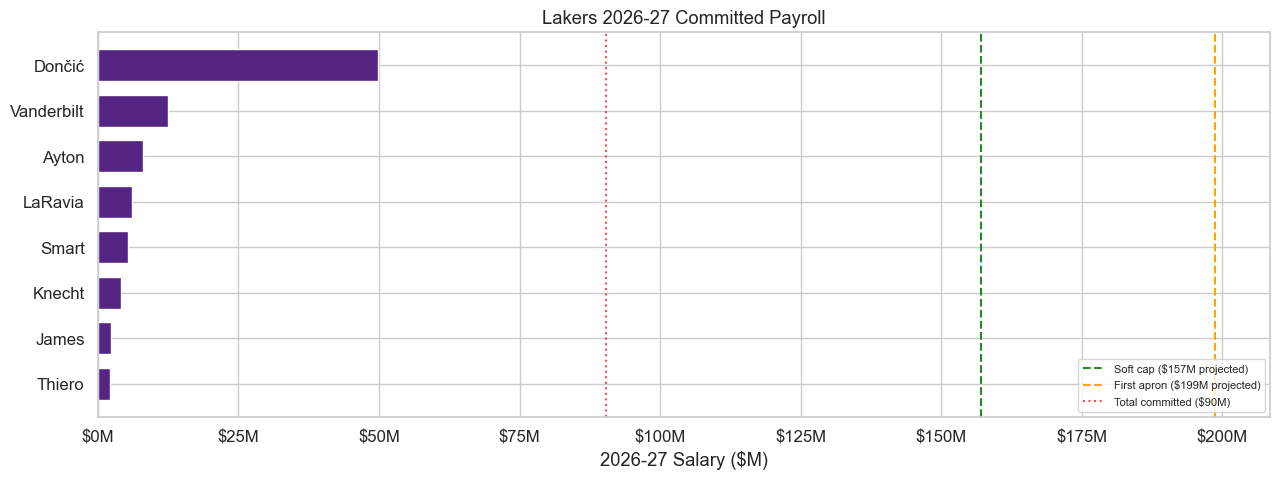

In [13]:
# Visual cap summary
fig, ax = plt.subplots(figsize=(13, 5))

players_with_salary = lakers[~lakers['IS_FREE_AGENT']].sort_values('2026-27', ascending=False)
names = players_with_salary['PLAYER_NAME'].str.split().str[-1].tolist()
salaries = (players_with_salary['2026-27'] / 1e6).tolist()

bar_colors = [LAKERS_GOLD if n in ['Doncic'] else LAKERS_PURPLE for n in names]
bars = ax.barh(names[::-1], salaries[::-1], color=bar_colors[::-1], height=0.7)

ax.axvline(SALARY_CAP_2026_27 / 1e6, color='forestgreen', linestyle='--', linewidth=1.5,
           label=f'Soft cap (${SALARY_CAP_2026_27/1e6:.0f}M projected)')
ax.axvline(FIRST_APRON_2026_27 / 1e6, color='orange', linestyle='--', linewidth=1.5,
           label=f'First apron (${FIRST_APRON_2026_27/1e6:.0f}M projected)')

total_bar_x = total_committed / 1e6
ax.axvline(total_bar_x, color='red', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Total committed (${total_committed/1e6:.0f}M)')

ax.set_xlabel('2026-27 Salary ($M)')
ax.set_title('Lakers 2026-27 Committed Payroll')
ax.legend(loc='lower right', fontsize=8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}M'))

plt.tight_layout()
plt.show()

**Reading the cap picture:**

The Lakers have significant committed payroll for 2026-27, led by Luka's supermax. The key question is how far they are from the second apron — teams above that threshold face severe trade restrictions (no salary aggregation, must trade down in total salary, lose access to most exceptions).

Several notable expiring contracts give the Lakers flexibility. LeBron, Rui Hachimura, Maxi Kleber, and Luke Kennard all come off the books. That's potentially significant cap relief — but also means roster holes that need filling.

**Bottom line:** The Lakers are likely a *trade team first* — they have committed salary to use as trade chips and will almost certainly operate above the luxury tax line regardless of offseason moves.

## E) Luka Complement Archetype Profiling

### The Methodology

Rather than K-means clustering 2025-26 players and checking which clusters historical Luka teammates land in, we go the other direction: **define archetypes from the historical teammates' actual data, then classify current players by distance to those archetypes.**

This fixes the key failure mode of the old approach: Brunson's 2025-26 Knicks profile (29 PPG primary creator) is very different from his 2021-22 Dallas profile (16 PPG complementary guard). The old approach used 2025-26 data for validation players, causing ball-dominant clusters to be labeled as Luka complement clusters.

**Four archetypes defined from Dallas Luka seasons:**
- **rim_runner**: Gafford, Lively, Powell (2023-24) — lob threats, finishers, low usage
- **three_and_d**: PJ Washington, DJJ, Josh Green (2023-24) + DFS, Bullock (2021-22) — switchable wings, 3PT shooters, defenders
- **secondary_creator**: Brunson, Dinwiddie (2021-22) — off-ball scoring guards who defer to Luka
- **shooter**: Tim Hardaway Jr., Maxi Kleber (2022-23) — spot-up specialists, stretch bigs

**Features used** (8 features available in nba_api cache for all seasons 2019-26):
`USG_PCT, AST_PCT, OREB_PCT, DREB_PCT, TS_PCT, NET_RATING, FG3_PCT, FG_PCT`

**Secondary creator USG gate**: Players with USG_PCT > 26% cannot be classified as secondary_creator, regardless of stylistic similarity. A player using 28%+ of possessions cannot realistically play off Luka's 35%+ usage.

**Complement filter**: `ARCHETYPE_DISTANCE < 2.5`. Players within this distance are 'in the filter' for the combined target score. Players outside get a 0.5x discount on their combined score.

In [14]:
# Validation table: which historical players were found and used to define archetypes
validation_rows = df.attrs.get('archetype_validation_rows', [])
if validation_rows:
    print('=== ARCHETYPE VALIDATION: HISTORICAL PLAYER RETRIEVAL ===')
    print('These are the Dallas Luka teammates used to define each archetype centroid.')
    print()
    val_df = pd.DataFrame(validation_rows)
    print(val_df[['Player', 'Season', 'Archetype', 'Found', 'Features Available', 'Features Imputed', 'Note']].to_string(index=False))
    print()
    found_count = val_df['Found'].sum()
    print(f'Total: {found_count}/{len(val_df)} players found with data')
    arch_counts = val_df[val_df['Note'] == 'OK'].groupby('Archetype').size()
    print('Players per archetype:', dict(arch_counts))
else:
    print('No validation data found in df.attrs')

=== ARCHETYPE VALIDATION: HISTORICAL PLAYER RETRIEVAL ===
These are the Dallas Luka teammates used to define each archetype centroid.

             Player  Season         Archetype  Found  Features Available  Features Imputed Note
     Daniel Gafford 2023-24        rim_runner   True                   8                 0   OK
   Dereck Lively II 2023-24        rim_runner   True                   8                 0   OK
      Dwight Powell 2023-24        rim_runner   True                   8                 0   OK
    P.J. Washington 2023-24       three_and_d   True                   8                 0   OK
  Derrick Jones Jr. 2023-24       three_and_d   True                   8                 0   OK
         Josh Green 2023-24       three_and_d   True                   8                 0   OK
   Tim Hardaway Jr. 2022-23           shooter   True                   8                 0   OK
        Maxi Kleber 2022-23           shooter   True                   8                 0   OK
D

In [15]:
# Archetype centroid profiles (mean feature values in scaled space)
from src.features.luka_complement import build_archetype_centroids, ARCHETYPE_FEATURES, _fit_scaler_on_current, _qualifying_mask

# Re-derive the centroids for display (they're already in df from compute_luka_complement)
validation_rows = df.attrs.get('archetype_validation_rows', [])
arch_names = df.attrs.get('archetype_centroid_names', [])
feat_list = df.attrs.get('archetype_features', ARCHETYPE_FEATURES)

print('=== ARCHETYPE CENTROID PROFILES (scaled space) ===')
print('Each value = standard deviations from 2025-26 league average for that feature')
print('Positive = above average, Negative = below average')
print()

# Show which current players are in each archetype
arch_members = df[df['BEST_ARCHETYPE'].notna()]
for arch in arch_names:
    members = arch_members[arch_members['BEST_ARCHETYPE'] == arch].sort_values('ARCHETYPE_DISTANCE')
    print(f'--- {arch.upper()} ({len(members)} current players) ---')
    for _, r in members.head(8).iterrows():
        fa_tag = ' [FA]' if r.get('IS_FREE_AGENT', False) else ''
        print(f'  {r["PLAYER_NAME"]:<28} dist={r["ARCHETYPE_DISTANCE"]:.2f}  SV={r.get("SURPLUS_VALUE",float("nan")):.3f}{fa_tag}')
    print()

=== ARCHETYPE CENTROID PROFILES (scaled space) ===
Each value = standard deviations from 2025-26 league average for that feature
Positive = above average, Negative = below average

--- RIM_RUNNER (11 current players) ---
  Goga Bitadze                 dist=1.36  SV=0.551
  Jakob Poeltl                 dist=1.45  SV=0.228
  Ryan Kalkbrenner             dist=1.63  SV=0.863
  Luke Kornet                  dist=1.82  SV=0.483
  Deandre Ayton                dist=1.98  SV=0.262
  Daniel Gafford               dist=2.14  SV=0.023
  Rudy Gobert                  dist=2.14  SV=0.030
  Isaiah Jackson               dist=2.32  SV=0.179

--- THREE_AND_D (81 current players) ---
  Tristan da Silva             dist=0.41  SV=0.205
  Toumani Camara               dist=0.53  SV=-0.232
  Zaccharie Risacher           dist=0.74  SV=-0.300
  Bruce Brown                  dist=0.82  SV=0.277 [FA]
  Kelly Oubre Jr.              dist=0.89  SV=0.386 [FA]
  Jake LaRavia                 dist=0.90  SV=0.051
  Moses Moo

In [16]:
# Per-archetype top trade targets
print('=== TOP 10 TRADE TARGETS PER ARCHETYPE (non-Lakers, under contract) ===')

arch_names = df.attrs.get('archetype_centroid_names', ['rim_runner', 'three_and_d', 'secondary_creator', 'shooter'])
for arch in arch_names:
    top = archetype_top_players(df, arch, n=10)
    top = top[top['TEAM_ABBREVIATION'] != 'LAL'] if 'TEAM_ABBREVIATION' in top.columns else top
    top_contract = top[~top['IS_FREE_AGENT']] if 'IS_FREE_AGENT' in top.columns else top
    print(f'\n--- {arch.upper()} ---')
    show_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
                 f'DIST_{arch.upper()}', 'SURPLUS_VALUE', 'AGE_ADJUSTED_SURPLUS', 'IS_FREE_AGENT']
    avail_cols = [c for c in show_cols if c in top_contract.columns]
    if not top_contract.empty:
        print(top_contract[avail_cols].head(6).to_string(index=False))
    else:
        print('  (no qualifying players found)')

=== TOP 10 TRADE TARGETS PER ARCHETYPE (non-Lakers, under contract) ===

--- RIM_RUNNER ---
     PLAYER_NAME TEAM_ABBREVIATION    AGE  DIST_RIM_RUNNER  SURPLUS_VALUE  AGE_ADJUSTED_SURPLUS
    Goga Bitadze               ORL 26.000            1.361          0.551                 0.551
    Jakob Poeltl               TOR 30.000            1.446          0.228                 0.205
Ryan Kalkbrenner               CHA 24.000            1.627          0.863                 0.993
     Luke Kornet               SAS 30.000            1.819          0.483                 0.435
  Daniel Gafford               DAL 27.000            2.138          0.023                 0.023
     Rudy Gobert               MIN 33.000            2.143          0.030                 0.020

--- THREE_AND_D ---
       PLAYER_NAME TEAM_ABBREVIATION    AGE  DIST_THREE_AND_D  SURPLUS_VALUE  AGE_ADJUSTED_SURPLUS
  Tristan da Silva               ORL 25.000             0.412          0.205                 0.205
    Toumani Camar

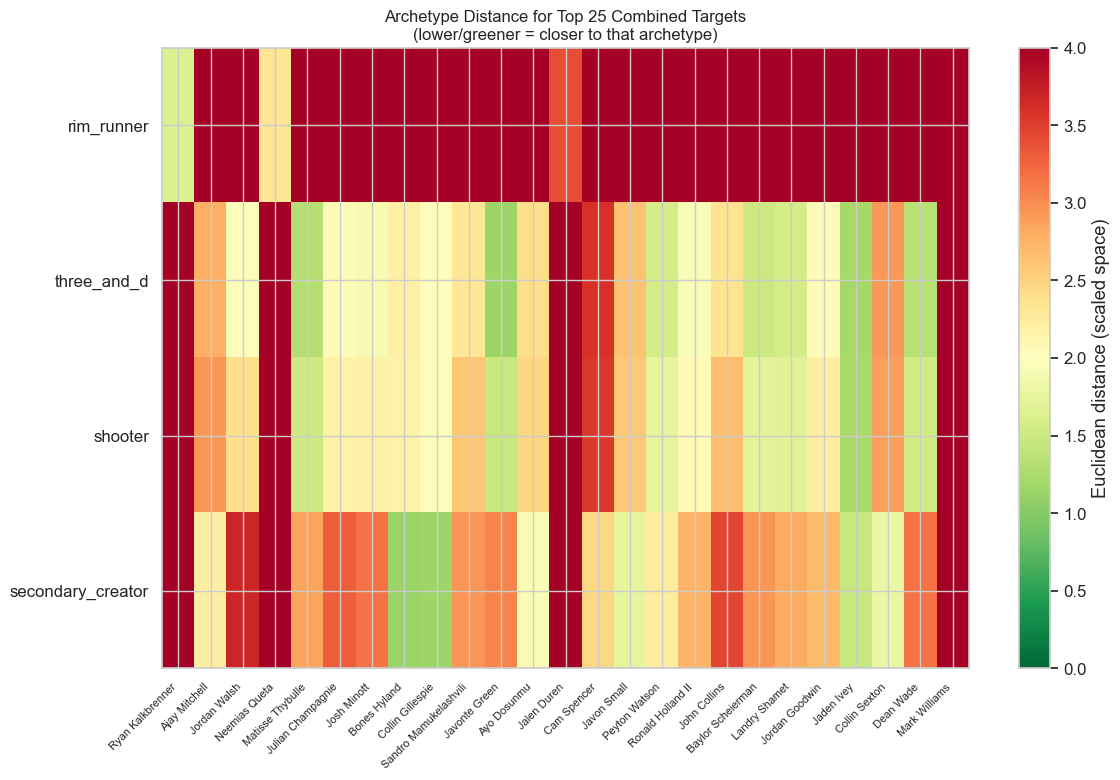

In [17]:
# Archetype distance heatmap for top targets
arch_names = df.attrs.get('archetype_centroid_names', ['rim_runner', 'three_and_d', 'secondary_creator', 'shooter'])
dist_cols = [f'DIST_{a.upper()}' for a in arch_names if f'DIST_{a.upper()}' in df.columns]

if dist_cols:
    # Show top 30 combined targets with their archetype distance profile
    plot_arch = df[
        df['COMBINED_TARGET_RANK'].notna() &
        (df['TEAM_ABBREVIATION'] != 'LAL')
    ].sort_values('COMBINED_TARGET_RANK').head(25)[['PLAYER_NAME', 'BEST_ARCHETYPE'] + dist_cols].copy()

    if not plot_arch.empty:
        fig, ax = plt.subplots(figsize=(12, 8))
        dist_matrix = plot_arch[dist_cols].values
        im = ax.imshow(dist_matrix.T, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=4)
        ax.set_xticks(range(len(plot_arch)))
        ax.set_xticklabels(plot_arch['PLAYER_NAME'].values, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(dist_cols)))
        ax.set_yticklabels([c.replace('DIST_', '').lower() for c in dist_cols])
        ax.set_title('Archetype Distance for Top 25 Combined Targets\n(lower/greener = closer to that archetype)', fontsize=12)
        plt.colorbar(im, ax=ax, label='Euclidean distance (scaled space)')
        plt.tight_layout()
        plt.show()
else:
    print('Distance columns not found')

In [18]:
# Summary: players closest to each archetype among ALL qualifying players (including Lakers)
print('=== CURRENT NBA PLAYERS CLOSEST TO EACH LUKA TEAMMATE ARCHETYPE ===')
print('Note: sorted by distance to that archetype (lower = closer match)')
print()

arch_names = df.attrs.get('archetype_centroid_names', ['rim_runner', 'three_and_d', 'secondary_creator', 'shooter'])
for arch in arch_names:
    top = archetype_top_players(df, arch, n=6)
    print(f'--- {arch.upper()} ---')
    show_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', f'DIST_{arch.upper()}', 'ON_COURT_VALUE', 'SURPLUS_VALUE']
    avail = [c for c in show_cols if c in top.columns]
    print(top[avail].to_string(index=False))
    print()

=== CURRENT NBA PLAYERS CLOSEST TO EACH LUKA TEAMMATE ARCHETYPE ===
Note: sorted by distance to that archetype (lower = closer match)

--- RIM_RUNNER ---
     PLAYER_NAME TEAM_ABBREVIATION  DIST_RIM_RUNNER  ON_COURT_VALUE  SURPLUS_VALUE
    Goga Bitadze               ORL            1.361           1.284          0.551
    Jakob Poeltl               TOR            1.446           1.022          0.228
Ryan Kalkbrenner               CHA            1.627           1.276          0.863
     Luke Kornet               SAS            1.819           1.462          0.483
   Deandre Ayton               LAL            1.984           0.480          0.262
  Daniel Gafford               DAL            2.138           0.467          0.023

--- THREE_AND_D ---
       PLAYER_NAME TEAM_ABBREVIATION  DIST_THREE_AND_D  ON_COURT_VALUE  SURPLUS_VALUE
  Tristan da Silva               ORL             0.412          -0.043          0.205
    Toumani Camara               POR             0.530          -0.093  

## F) Roll Gravity, Rim Protection, and Big-Man Fit Scores

**Roll Gravity** captures lob threat / rim presence value: restricted-area finishing (NORMAL_FG_PCT),
offensive rebounding (OREB_PCT), and low usage (doesn't compete with Luka for creation reps).
BLK% was removed from this score -- rim protection is a *separate* dimension.

**Rim Protection** captures defensive anchor value: shot-blocking rate (BLK%) and defensive
rebounding (DREB_PCT). Some bigs (e.g. Lively) excel as lob threats but are still developing
defensively; others (Williams III) excel at both.

**Big-Man Fit Score** = Roll Gravity + Rim Protection. Identifies the bigs who fill both
Luka-specific needs simultaneously.


In [19]:
# Roll Gravity, Rim Protection, and Big-Man Fit leaderboards
score_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'ROLL_GRAVITY_SCORE', 'ROLL_GRAVITY_RANK',
    'RIM_PROTECTION_SCORE', 'RIM_PROTECTION_RANK',
    'BIG_MAN_FIT_SCORE', 'BIG_MAN_FIT_RANK',
    'ON_COURT_VALUE', 'SURPLUS_VALUE',
]
available_cols = [c for c in score_cols if c in df.columns]

print('=== TOP 25 ROLL GRAVITY (lob threat / finishing) ===')
has_rg = df['ROLL_GRAVITY_SCORE'].notna()
print(df[has_rg][available_cols].nsmallest(25, 'ROLL_GRAVITY_RANK').to_string(index=False))

print('\n=== TOP 25 RIM PROTECTION (defensive anchor) ===')
has_rp = df['RIM_PROTECTION_SCORE'].notna() if 'RIM_PROTECTION_SCORE' in df.columns else pd.Series(False, index=df.index)
if has_rp.any():
    rp_cols = [c for c in available_cols if c != 'ROLL_GRAVITY_RANK']
    print(df[has_rp][rp_cols].nsmallest(25, 'RIM_PROTECTION_RANK').to_string(index=False))

print('\n=== TOP 25 BIG-MAN FIT (roll gravity + rim protection combined) ===')
has_bmf = df['BIG_MAN_FIT_SCORE'].notna() if 'BIG_MAN_FIT_SCORE' in df.columns else pd.Series(False, index=df.index)
if has_bmf.any():
    bmf_cols = [c for c in available_cols]
    print(df[has_bmf][bmf_cols].nsmallest(25, 'BIG_MAN_FIT_RANK').to_string(index=False))


=== TOP 25 ROLL GRAVITY (lob threat / finishing) ===
        PLAYER_NAME TEAM_ABBREVIATION    AGE  ROLL_GRAVITY_SCORE  ROLL_GRAVITY_RANK  RIM_PROTECTION_SCORE  RIM_PROTECTION_RANK  BIG_MAN_FIT_SCORE  BIG_MAN_FIT_RANK  ON_COURT_VALUE  SURPLUS_VALUE
       Steven Adams               HOU 32.000               7.943              1.000                 1.223               74.000              9.166             7.000           0.365          0.087
  Mitchell Robinson               NYK 28.000               7.850              2.000                 4.927                5.000             12.777             1.000           1.556          0.966
     Dylan Cardwell               SAC 24.000               6.679              3.000                 4.878                6.000             11.557             2.000          -0.157          0.429
     Andre Drummond               PHI 32.000               6.295              4.000                 4.084               11.000             10.379             5.000    

In [20]:
# Validation check: did Gafford, DJJ, Lively show up?
validation_roll_gravity = {
    'Daniel Gafford': 1629655,
    'Derrick Jones Jr': 1628407,
}
# Jalen Duren as additional proxy (elite rim runner)
extra_check = {'Jalen Duren': 1631096}

print('=== ROLL GRAVITY VALIDATION CHECK ===')
for name, pid in {**validation_roll_gravity, **extra_check}.items():
    row = df[df['PLAYER_ID'] == pid]
    if len(row) == 0:
        print(f'{name}: NOT in 2025-26 dataset')
    else:
        r = row.iloc[0]
        rg = r['ROLL_GRAVITY_SCORE']
        rank = r['ROLL_GRAVITY_RANK']
        status = 'PASS' if pd.notna(rg) and rg > 0 else 'FAIL'
        print(f'{name}: score={rg:.2f}, rank={rank:.0f} [{status}]')

=== ROLL GRAVITY VALIDATION CHECK ===
Daniel Gafford: score=4.76, rank=18 [PASS]
Derrick Jones Jr: NOT in 2025-26 dataset
Jalen Duren: score=1.46, rank=75 [PASS]


In [21]:
# High roll gravity AND undervalued (the best trade targets for rim depth)
print('=== HIGH ROLL GRAVITY + UNDERVALUED (non-Laker) ===')
rg_surplus = df[
    df['ROLL_GRAVITY_SCORE'].notna() &
    (df['ROLL_GRAVITY_SCORE'] > 1.5) &
    df['SURPLUS_VALUE'].notna() &
    (df['SURPLUS_VALUE'] > 0) &
    (df['TEAM_ABBREVIATION'] != 'LAL')
]
rg_surplus_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'ROLL_GRAVITY_SCORE',
                   'ON_COURT_VALUE', 'SURPLUS_VALUE', 'IS_FREE_AGENT']
avail_rgs = [c for c in rg_surplus_cols if c in rg_surplus.columns]
rg_surplus.sort_values('ROLL_GRAVITY_SCORE', ascending=False)[avail_rgs]

=== HIGH ROLL GRAVITY + UNDERVALUED (non-Laker) ===


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ROLL_GRAVITY_SCORE,ON_COURT_VALUE,SURPLUS_VALUE,IS_FREE_AGENT
511,Steven Adams,HOU,32.000,7.943,0.365,0.087,False
405,Mitchell Robinson,NYK,28.000,7.850,1.556,0.966,True
167,Dylan Cardwell,SAC,24.000,6.679,-0.157,0.429,True
24,Andre Drummond,PHI,32.000,6.295,-0.192,0.411,True
153,Donovan Clingan,POR,22.000,5.953,0.815,0.430,False
375,Luke Kornet,SAS,30.000,5.865,1.462,0.483,False
414,Moussa Diabaté,CHA,24.000,5.708,1.190,0.837,False
487,Ryan Kalkbrenner,CHA,24.000,5.412,1.276,0.863,False
483,Rudy Gobert,MIN,33.000,5.334,0.914,0.030,False
323,Kel'el Ware,MIA,22.000,5.201,0.642,0.498,False


## G) Combined Target List: Who Should the Lakers Target?

Now we combine everything into a single ranked list.

**Scoring logic (filter-then-rank):**
1. **Filter**: Is this player within `ARCHETYPE_DISTANCE < 2.5` of a historical Luka complement archetype?
2. **Rank**: Among filtered players, rank by `AGE_ADJUSTED_SURPLUS` (production relative to contract cost, adjusted for age trajectory).
3. **Discount**: Players outside the archetype filter get a 0.5x penalty on their score — they still appear but ranked lower.

High combined score = undervalued on their contract AND a stylistic fit for Luka's system.

Free agents are ranked by their `VALUE_PERCENTILE × AGE_FACTOR` (full production value, no contract cost).

In [22]:
# Top 30 combined targets (non-Lakers)
combined_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'COMBINED_TARGET_SCORE', 'COMBINED_TARGET_RANK',
    'ON_COURT_VALUE', 'SURPLUS_VALUE', 'AGE_ADJUSTED_SURPLUS',
    'BEST_ARCHETYPE', 'ARCHETYPE_DISTANCE',
    'ROLL_GRAVITY_SCORE', 'IS_FREE_AGENT', 'SALARY_FORWARD'
]
avail_cb = [c for c in combined_cols if c in df.columns]

non_laker_mask = (
    (df['TEAM_ABBREVIATION'] != 'LAL') &
    df['COMBINED_TARGET_RANK'].notna()
)

targets = df[non_laker_mask].sort_values('COMBINED_TARGET_RANK').head(30)[avail_cb].copy()

if 'SALARY_FORWARD' in targets.columns:
    targets['SALARY_FORWARD'] = targets['SALARY_FORWARD'].apply(
        lambda x: f'${x/1e6:.1f}M' if pd.notna(x) else 'FA'
    )

targets

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,COMBINED_TARGET_SCORE,COMBINED_TARGET_RANK,ON_COURT_VALUE,SURPLUS_VALUE,AGE_ADJUSTED_SURPLUS,BEST_ARCHETYPE,ARCHETYPE_DISTANCE,ROLL_GRAVITY_SCORE,IS_FREE_AGENT,SALARY_FORWARD
487,Ryan Kalkbrenner,CHA,24.000,2.454,1.000,1.276,0.863,0.993,rim_runner,1.627,5.412,False,$2.4M
11,Ajay Mitchell,OKC,23.000,2.090,3.000,1.027,0.749,0.861,secondary_creator,2.210,-1.905,False,$2.9M
297,Jordan Walsh,BOS,22.000,2.054,4.000,0.578,0.679,0.848,three_and_d,1.964,1.775,False,$2.4M
422,Neemias Queta,BOS,26.000,2.047,5.000,1.617,0.846,0.846,rim_runner,2.328,4.639,False,$2.7M
391,Matisse Thybulle,POR,29.000,1.998,6.000,1.045,0.920,0.828,three_and_d,1.313,-0.137,True,FA
306,Julian Champagnie,SAS,24.000,1.902,7.000,0.866,0.690,0.794,three_and_d,2.045,-0.114,False,$3.0M
302,Josh Minott,BKN,23.000,1.860,8.000,0.743,0.677,0.778,three_and_d,1.913,0.995,False,$2.6M
52,Bones Hyland,MIN,25.000,1.841,9.000,0.586,0.771,0.771,secondary_creator,1.129,-2.113,True,FA
104,Collin Gillespie,PHX,26.000,1.793,10.000,0.549,0.754,0.754,secondary_creator,1.143,-0.557,True,FA
493,Sandro Mamukelashvili,TOR,27.000,1.768,11.000,1.010,0.745,0.745,three_and_d,2.312,0.702,False,$2.8M


In [27]:
# Split view: top trade targets (under contract) vs top FA targets
under_contract = df[
    ~df['IS_FREE_AGENT'] &
    (df['TEAM_ABBREVIATION'] != 'LAL') &
    df['SURPLUS_VALUE'].notna() &
    df['ARCHETYPE_DISTANCE'].notna()
].copy()

fa_targets = df[
    df['IS_FREE_AGENT'] &
    #(df['TEAM_ABBREVIATION'] != 'LAL') &
    df['ON_COURT_VALUE'].notna()
].copy()

# Lakers internal free agent decisions
lal_fas = df[
    df['IS_FREE_AGENT'] & 
    (df['TEAM_ABBREVIATION'] == 'LAL') &
    df['ON_COURT_VALUE'].notna()
].sort_values('ON_COURT_VALUE', ascending=False)

trade_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
              'SURPLUS_VALUE', 'AGE_ADJUSTED_SURPLUS', 'BEST_ARCHETYPE', 'ARCHETYPE_DISTANCE', 'ROLL_GRAVITY_SCORE']
fa_cols_view = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
                'ON_COURT_VALUE', 'VALUE_PERCENTILE', 'AGE_FACTOR', 'BEST_ARCHETYPE', 'ARCHETYPE_DISTANCE']

print('=== TOP 15 TRADE TARGETS (players under 2026-27 contract) ===')
print('Ranked by AGE_ADJUSTED_SURPLUS among players with ARCHETYPE_DISTANCE < 2.5 (non-Lakers)')
print()
avail_trade = [c for c in trade_cols if c in under_contract.columns]
in_arch_filter = under_contract['ARCHETYPE_DISTANCE'] < 2.5
trade_targets = under_contract[in_arch_filter].sort_values('AGE_ADJUSTED_SURPLUS', ascending=False).head(15)
print(trade_targets[avail_trade].to_string(index=False))

=== TOP 15 TRADE TARGETS (players under 2026-27 contract) ===
Ranked by AGE_ADJUSTED_SURPLUS among players with ARCHETYPE_DISTANCE < 2.5 (non-Lakers)

          PLAYER_NAME TEAM_ABBREVIATION    AGE  SURPLUS_VALUE  AGE_ADJUSTED_SURPLUS    BEST_ARCHETYPE  ARCHETYPE_DISTANCE  ROLL_GRAVITY_SCORE
     Ryan Kalkbrenner               CHA 24.000          0.863                 0.993        rim_runner               1.627               5.412
        Ajay Mitchell               OKC 23.000          0.749                 0.861 secondary_creator               2.210              -1.905
         Jordan Walsh               BOS 22.000          0.679                 0.848       three_and_d               1.964               1.775
        Neemias Queta               BOS 26.000          0.846                 0.846        rim_runner               2.328               4.639
    Julian Champagnie               SAS 24.000          0.690                 0.794       three_and_d               2.045              -0.1

In [28]:
print('=== TOP 15 FREE AGENT TARGETS (no 2026-27 contract) ===')
print('These players can potentially be signed without trading assets.')
print('Ranked by ON_COURT_VALUE (production, unconstrained by cost).')
print()
avail_fa_v = [c for c in fa_cols_view if c in fa_targets.columns]
print(fa_targets.nlargest(15, 'ON_COURT_VALUE')[avail_fa_v].to_string(index=False))

=== TOP 15 FREE AGENT TARGETS (no 2026-27 contract) ===
These players can potentially be signed without trading assets.
Ranked by ON_COURT_VALUE (production, unconstrained by cost).

        PLAYER_NAME TEAM_ABBREVIATION    AGE  ON_COURT_VALUE  VALUE_PERCENTILE  AGE_FACTOR    BEST_ARCHETYPE  ARCHETYPE_DISTANCE
        Jalen Duren               DET 22.000           2.022             0.989       1.250              None               3.397
Robert Williams III               POR 28.000           1.617             0.971       1.000              None               3.324
  Mitchell Robinson               NYK 28.000           1.556             0.966       1.000              None               3.580
       Jaxson Hayes               LAL 26.000           1.283             0.949       1.000              None               8.406
   Matisse Thybulle               POR 29.000           1.045             0.920       0.900       three_and_d               1.313
      Mark Williams               PHX 24.00

In [ ]:
print('=== LAKERS FREE AGENTS ===')
print('These are the decisions Lakers make first.')
print('Ranked by ON_COURT_VALUE (production, unconstrained by cost).')
print()
avail_fa_v = [c for c in fa_cols_view if c in lal_fas.columns]
print(lal_fas[avail_fa_v].to_string(index=False))

=== LAKERS FREE AGENTS ===
These players can potentially be signed without trading assets.
Ranked by ON_COURT_VALUE (production, unconstrained by cost).

  PLAYER_NAME TEAM_ABBREVIATION    AGE  ON_COURT_VALUE  VALUE_PERCENTILE  AGE_FACTOR    BEST_ARCHETYPE  ARCHETYPE_DISTANCE
 Jaxson Hayes               LAL 26.000           1.283             0.949       1.000              None               8.406
Austin Reaves               LAL 27.000           0.961             0.894       1.000 secondary_creator               1.867
 LeBron James               LAL 41.000           0.704             0.806       0.500              None               4.041
 Luke Kennard               LAL 29.000           0.589             0.777       0.900              None               2.868
Rui Hachimura               LAL 28.000          -0.062             0.477       1.000       three_and_d               1.561


In [25]:
# Summary visualization: top targets bubble chart -- Plotly for interactive tooltips

plot_targets = df[
    (df['TEAM_ABBREVIATION'] != 'LAL') &
    df['ON_COURT_VALUE'].notna() &
    df['ARCHETYPE_DISTANCE'].notna()
].copy()

val_col = 'AGE_ADJUSTED_SURPLUS' if 'AGE_ADJUSTED_SURPLUS' in plot_targets.columns else 'SURPLUS_VALUE'
plot_targets['_value'] = plot_targets[val_col].fillna(0)
plot_targets['_arch'] = plot_targets['BEST_ARCHETYPE'].fillna('no fit')
plot_targets['_salary_str'] = plot_targets['SALARY_FORWARD'].apply(
    lambda x: f'${x/1e6:.1f}M' if pd.notna(x) else 'FA'
)
# Clip ON_COURT_VALUE to [0, inf] for bubble size (negative values not allowed)
plot_targets['_size'] = plot_targets['ON_COURT_VALUE'].clip(lower=0)

arch_colors = {
    'rim_runner': 'darkorange',
    'three_and_d': 'steelblue',
    'secondary_creator': 'forestgreen',
    'shooter': 'mediumpurple',
    'no fit': 'lightgray',
}

fig = px.scatter(
    plot_targets.nlargest(80, val_col),
    x='ARCHETYPE_DISTANCE',
    y='_value',
    color='_arch',
    color_discrete_map=arch_colors,
    size='_size',
    size_max=25,
    hover_name='PLAYER_NAME',
    hover_data={
        'TEAM_ABBREVIATION': True,
        'AGE': True,
        '_salary_str': True,
        'SURPLUS_VALUE': ':.3f',
        'ARCHETYPE_DISTANCE': ':.2f',
        '_value': ':.3f',
        '_arch': False,
        '_size': False,
    },
    title='Luka Complement Targets: Value vs. Archetype Fit<br><sup>Size = ON_COURT_VALUE | Color = best archetype | Left = closer fit</sup>',
    labels={
        'ARCHETYPE_DISTANCE': 'Archetype Distance (lower = better fit)',
        '_value': f'{val_col}',
        '_arch': 'Archetype',
    },
)

fig.add_vline(x=2.5, line_dash='dash', line_color='red',
             annotation_text='Filter threshold (2.5)', annotation_position='top')
fig.update_layout(width=1000, height=700, legend_title='Archetype')
fig.show()

### Top Targets Bubble Chart Findings

Some interesting and unexpected names surfaced in the analysis. Top 2-3 players for each archetype listed below

- Rim Runners
    - Ryan Kalkbrenner [Highest age adjusted surplus value and right at the top with low archetype distance]
    - Neemias Quetta [Another excellent undervalued contract, and impossible to get Celtics player]

- 3&D
    - Jordan Walsh
    - Mattise Thybulle [Unexpected and intriguing name, 1.31 archetype distance]

- Secondary Creators
    - Ajay Mitchell
    - Bones Hyland [Another great find, one of the lowest archetype distances]
    - Colin Gillespie

- Shooters (only 3 showed up and all with low on court value, so potentially just made for short burst role players)
    - Simon Fontechhio
    - Norman Powell


Other interesting names are Goga Bitadze, Cam Spencer, Javonte Green who could be feasible trade targets. Payton Prichard was another excellent mention, marked as Secondary creator but well respected for his shooting and defence as well, even though he is not the Wing associated with 3&D archetype, a net positive addition to any team. Baylor Scheierman and Landry Shamet proving their worth this season showing why they are excellent value players, spotted by our model. 
Jalen Duren, Robert Williams III were interesting omissions who failed the archetype test. On paper they seem like great fits but were modelled out. 


## H) Methodology Notes and Limitations

### Weights and Thresholds (Phase 1.5b)

Every weight, threshold, and modeling choice is a starting hypothesis. Constants are defined at the
top of their respective modules for transparency.

| Parameter | Value | Location | Rationale |
|-----------|-------|----------|-----------|
| BPM weight | 35% | `player_value.py::ON_COURT_WEIGHTS` | Best individual-impact metric, independent of team context |
| VORP weight | 0% (removed) | `player_value.py::ON_COURT_WEIGHTS` | Derived from BPM x minutes -- double-counts BPM |
| WS/48 weight | 20% | `player_value.py::ON_COURT_WEIGHTS` | Different methodology from BPM; genuine additional signal |
| NET_RATING weight | 25% | `player_value.py::ON_COURT_WEIGHTS` | Team-level on/off impact; captures defensive contributions BPM misses |
| TS% weight | 20% | `player_value.py::ON_COURT_WEIGHTS` | Pure scoring efficiency; independent axis |
| Min GP | 20 | `player_value.py::MIN_GP` | Small-sample exclusion |
| Min MIN/game | 15 | `player_value.py::MIN_MIN` | Garbage-time exclusion |
| Z-score population | Qualifying only | `player_value.py` | Mean/std from rotation players; 0 = average rotation player |
| Surplus methodology | Percentile-rank | `player_value.py` | VALUE_PERCENTILE - SALARY_PERCENTILE; handles skewed salary distribution |
| Age factor | Step function | `player_value.py::age_factor()` | Peak 25-28; penalty after 28; bonus before 25 |
| Archetype validation seasons | 2021-22, 2022-23, 2023-24 | `luka_complement.py::DALLAS_ARCHETYPE_MAP` | Dallas teammates from Luka's three most relevant seasons |
| Archetype features | 8 nba_api features | `luka_complement.py::ARCHETYPE_FEATURES` | USG, AST%, OREB%, DREB%, TS%, NET_RATING, FG3%, FG% -- available all seasons |
| Archetype filter threshold | 2.5 | `luka_complement.py::ARCHETYPE_DISTANCE_THRESHOLD` | Distance gate; players outside get 0.5x discount on combined score |
| Secondary creator USG cap | 26% | `luka_complement.py` | Players > 26% USG excluded from secondary_creator (can't play off Luka's 35%+ USG) |
| Forward salary cap | $157M | `constants.py::SALARY_CAP_2026_27` | ~2% projected growth from 2025-26 |
| YEARS_REMAINING | 2026-27 onward only | `salaries.py` | 2025-26 season is over for trade analysis purposes |
| Austin Reaves | IS_FREE_AGENT=True | `constants.py::PLAYER_OPTION_OVERRIDES` | PO decline hardcoded; he will seek max extension |

### Known Limitations

**1. System effects are real and unresolved.**  
All of BPM, WS, VORP, and NET_RATING measure outcomes in a player's actual team context. A player
on a great team with great spacing looks better than an equivalent player on a bad team.

**2. Defensive metrics are thin.**  
The only direct defensive signal from nba_api is the close-defense FG% differential (`PCT_PLUSMINUS`).
Defensive BPM from BBRef is the best available proxy. Elite defenders may be underrated.

**3. No restricted-area FG% for roll gravity.**  
We use `NORMAL_FG_PCT` as a proxy for restricted-area finishing. Zone-specific shooting data would be cleaner.

**4. Archetype features use a minimal common set.**  
Catch-and-shoot data, defensive matchup data, BBRef STL%/BLK% are only cached for 2024-26.
The 8 archetype features (USG, AST%, OREB%, DREB%, TS%, NET_RATING, FG3%, FG%) are available for all seasons 2019-26
and were sufficient to retrieve all 12 historical validation players with complete data.

**5. Secondary creator archetype overlaps with ball-dominant guards.**  
The 8 generic features cannot fully distinguish 'secondary creator who defers to Luka' from 'primary creator on their own team.'
De'Aaron Fox (USG=24.2% in 2025-26 on SA, where he plays next to Wembanyama) appears as secondary_creator by the model.
This reflects his actual 2025-26 role data, not just his historical reputation. Whether he would replicate this
deference role next to Luka is a basketball judgment the model cannot make.

**6. Salary data is 2025-26 season only.**  
YEARS_REMAINING is computed from the BBRef CSV forward columns. Player options are manually hardcoded.

**7. Age curve is a step function, not empirically fitted.**  
Phase 2 will replace this with a fitted aging curve from career trajectories.

### Future Improvements

- **EPM / LEBRON**: Better all-in-one metrics that isolate individual impact from team effects
- **Play-type data**: Roll-man FGA/FG% from PBP Stats would replace the NORMAL_FG_PCT proxy
- **Fitted aging curve**: Historical career trajectories replacing the current step function
- **Playoff data**: 2023-24 Dallas playoff stats could validate archetypes in high-leverage scenarios
- **Lineup data**: Empirically measuring which player types produce best alongside ball-dominant creators


In [26]:
# Save the fully valued dataset for downstream use
import os
output_path = '../data/cache/player_valued_2025-26.parquet'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_parquet(output_path, index=False)
print(f'Saved valued dataset to {output_path}')
print(f'Shape: {df.shape}')
print('\nNew columns added in Phase 1:')
new_cols = [c for c in df.columns if c not in raw.columns]
print(new_cols)

Saved valued dataset to ../data/cache/player_valued_2025-26.parquet
Shape: (582, 221)

New columns added in Phase 1:
['Z_BPM', 'Z_VORP', 'Z_WS', 'Z_WS_48', 'Z_NET_RATING', 'Z_TS_PCT', 'ON_COURT_VALUE', 'SALARY_CURRENT', 'SALARY_FORWARD', 'IS_FREE_AGENT', 'CONTRACT_VALUE', 'SALARY_RANK_PCT', 'CONTRACT_VALUE_Z', 'VALUE_PERCENTILE', 'SALARY_PERCENTILE', 'SURPLUS_VALUE', 'SURPLUS_RANK', 'AGE_FACTOR', 'AGE_ADJUSTED_SURPLUS', 'DURABILITY_SCORE', 'MAJOR_INJURY_FLAGS', 'ADJUSTED_VALUE', 'DIST_RIM_RUNNER', 'DIST_THREE_AND_D', 'DIST_SHOOTER', 'DIST_SECONDARY_CREATOR', 'ARCHETYPE_DISTANCE', 'BEST_ARCHETYPE', 'ROLL_GRAVITY_SCORE', 'ROLL_GRAVITY_RANK', 'RIM_PROTECTION_SCORE', 'RIM_PROTECTION_RANK', 'BIG_MAN_FIT_SCORE', 'BIG_MAN_FIT_RANK', 'COMBINED_TARGET_SCORE', 'COMBINED_TARGET_RANK']
